In [1]:
cd ..

c:\Users\Yago\Desktop\MAADM\5 Sistemas de Recomendación\practica2


# Reto 2 - SISTEMA DE RECOMENDACIÓN BASADA EN CONTENIDO

$$
rating = f(Usuario, Local, Interacción_{U-L}, Contexto)
$$

In [2]:
from pathlib import Path

import numpy as np
import polars as pl

In [3]:
DATA_DIR = Path("./data")
RESULTS_DIR = Path("./results")
RESULTS_DIR.mkdir(exist_ok=True)
TRAIN_FILE = DATA_DIR / "train_reviews.csv"
TEST_FILE = DATA_DIR / "test_reviews.csv"
BUSINESS_FILE = DATA_DIR / "negocios.csv"
USER_FILE = DATA_DIR / "usuarios.csv"
OUTPUT_FILE = RESULTS_DIR / "submission.csv"

## 1. Carga de datos

In [4]:
COUNTER_COLS = ["useful", "funny", "cool"]

train = pl.read_csv(TRAIN_FILE, infer_schema=20_000).with_columns(
    [pl.col(c).clip(lower_bound=0) for c in COUNTER_COLS]).with_columns(
    pl.col("date").str.strptime(pl.Datetime, "%Y-%m-%d %H:%M:%S").alias("datetime"),
).with_columns(
    pl.col("datetime").dt.date().alias("date"))
test = pl.read_csv(TEST_FILE, infer_schema=20_000).with_columns(
    pl.col("date").str.strptime(pl.Datetime, "%Y-%m-%d %H:%M:%S").alias("datetime"),
).with_columns(
    pl.col("datetime").dt.date().alias("date"))


display(train.head())

review_id,user_id,business_id,stars,useful,funny,cool,date,datetime
str,str,str,f64,i64,i64,i64,date,datetime[μs]
"""ZZO43qKB-s65zplC8RfJqw""","""-1BSu2dt_rOAqllw9ZDXtA""","""smkZq4G1AOm4V6p3id5sww""",5.0,0,0,0,2016-09-30,2016-09-30 15:49:32
"""vojXOF_VOgvuKD95gCO8_Q""","""xpe178ng_gj5X6HgqtOing""","""96_c_7twb7hYRZ9HHrq01g""",1.0,2,0,1,2020-12-09,2020-12-09 14:39:51
"""KwxdbiseRlIRNzpgvyjY0Q""","""axbaerf2Fk92OB4b9_peVA""","""e0AYjKfSF0DL-5C1CpOq6Q""",4.0,0,0,0,2013-09-04,2013-09-04 16:19:51
"""3mwoBcTy-2gMh0L91uaIeA""","""_GOiybb0rImYKJfwyxEaGg""","""vF-uptiQ34pVLHJKzPHUlA""",5.0,0,0,0,2019-03-02,2019-03-02 12:24:14
"""XfWf7XsBWs3kYyYq7Ns1ZQ""","""ojWKg3B5pH3ncAsxun3kUw""","""X28XK71RuEXPapeyUOwNzg""",5.0,10,4,7,2020-04-23,2020-04-23 18:26:29


In [5]:
businesses = pl.read_csv(BUSINESS_FILE, infer_schema=20_000)
display(businesses.head())

business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
str,str,str,str,str,str,f64,f64,f64,i64,i64,str,str,str
"""GDEEPQdYs2utMN-R4znZSA""","""Metro Self Storage - Largo""","""10501 S Belcher Rd""","""Largo""","""FL""","""33777""",27.868519,-82.743849,4.5,7,0,"""{'BusinessAcceptsCreditCards':…","""Packing Supplies, Shopping, Lo…","""{'Monday': '0:0-0:0', 'Tuesday…"
"""pbAq2NRG_2jCBI6fgRalvQ""","""Madewell""","""3301 Veterans Blvd, Ste 84""","""Metairie""","""LA""","""70002""",30.005894,-90.15745,2.0,6,1,"""{'BusinessAcceptsCreditCards':…","""Shopping, Women's Clothing, Fa…","""{'Monday': '10:0-21:0', 'Tuesd…"
"""h4HP3Vc0dQq7SfSLal9qQw""","""Dollylocks""","""511 9th St N""","""Saint Petersburg""","""FL""","""33701""",27.777785,-82.646673,4.5,7,0,"""{'RestaurantsPriceRange2': '4'…","""Hair Stylists, Beauty & Spas, …",null
"""PndbFVbHE4730HDlghxv6g""","""Jim Browne Chrysler Jeep Dodge…","""10909 N Florida Ave""","""Tampa""","""FL""","""33612""",28.048093,-82.458757,2.5,76,1,"""{'BusinessAcceptsCreditCards':…","""Automotive, Auto Parts & Suppl…","""{'Monday': '7:30-20:0', 'Tuesd…"
"""IayDnngl0NooAbcoo62j-w""","""Emg Salons""","""324 S Falkenburg Rd""","""Tampa""","""FL""","""33619""",27.948815,-82.334619,4.5,7,1,"""{'WiFi': ""u'free'"", 'BikeParki…","""Hair Stylists, Hair Salons, Be…","""{'Tuesday': '9:0-20:0', 'Wedne…"


In [6]:
users = pl.read_csv(USER_FILE, infer_schema=20_000)
display(users.head())

user_id,name,review_count,yelping_since,useful,funny,cool,elite,friends,fans,average_stars,compliment_hot,compliment_more,compliment_profile,compliment_cute,compliment_list,compliment_note,compliment_plain,compliment_cool,compliment_funny,compliment_writer,compliment_photos
str,str,i64,str,i64,i64,i64,str,str,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""qVc8ODYU5SZjKXVBgXdI7w""","""Walker""",585,"""2007-01-25 16:47:26""",7217,1259,5994,"""2007""","""NSCy54eWehBJyZdG2iE84w, pe42u7…",267,3.91,250,65,55,56,18,232,844,467,467,239,180
"""j14WgRoU_-2ZE1aw1dXrJg""","""Daniel""",4333,"""2009-01-25 04:35:42""",43091,13066,27281,"""2009,2010,2011,2012,2013,2014,…","""ueRPE0CX75ePGMqOFVj6IQ, 52oH4D…",3138,3.74,1145,264,184,157,251,1847,7054,3131,3131,1521,1946
"""2WnXYQFK0hXEoTxPtV2zvg""","""Steph""",665,"""2008-07-25 10:41:00""",2086,1010,1003,"""2009,2010,2011,2012,2013""","""LuO3Bn4f3rlhyHIaNfTlnA, j9B4Xd…",52,3.32,89,13,10,17,3,66,96,119,119,35,18
"""SZDeASXq7o05mMNLshsdIA""","""Gwen""",224,"""2005-11-29 04:38:33""",512,330,299,"""2009,2010,2011""","""enx1vVPnfdNUdPho6PH_wg, 4wOcvM…",28,4.27,24,4,1,6,2,12,16,26,26,10,9
"""q_QQ5kBBwlCcbL1s4NVK3g""","""Jane""",1221,"""2005-03-14 20:26:35""",14953,9940,11211,"""2006,2007,2008,2009,2010,2011,…","""xBDpTUbai0DXrvxCe3X16Q, 7GPNBO…",1357,3.85,1713,163,191,361,147,1212,5696,2543,2543,815,323


## 2. Creación de los datos de entrada - Offline

### 2.1 Usuario

In [7]:
from datetime import datetime

users_mean_avg_stars = users.select(pl.col("average_stars").mean()).item()
user_df = (
    users.select(
        pl.col("user_id"),
        pl.col("review_count"),
        pl.col("yelping_since"),
        pl.col("useful"),
        pl.col("funny"),
        pl.col("cool"),
        pl.col("elite"),
        pl.col("friends"),
        pl.col("fans"),
        pl.col("average_stars"),
        pl.col("compliment_hot"),
        pl.col("compliment_more"),
        pl.col("compliment_profile"),
        pl.col("compliment_cute"),
        pl.col("compliment_list"),
        pl.col("compliment_note"),
        pl.col("compliment_plain"),
        pl.col("compliment_cool"),
        pl.col("compliment_funny"),
        pl.col("compliment_writer"),
        pl.col("compliment_photos"),
    )
    .with_columns(
        (pl.col("review_count")+1).log10().fill_null(0).alias("user_review_count_log"),
        (pl.col("fans") + 1).log10().fill_null(0).alias("user_fans_log"),
        (pl.col("useful") + 1).log10().fill_null(0).alias("user_useful_log"),
        (pl.col("funny") + 1).log10().fill_null(0).alias("user_funny_log"),
        (pl.col("cool") + 1).log10().fill_null(0).alias("user_cool_log"),
        pl.col("yelping_since")
        .str.strptime(pl.Date, format="%Y-%m-%d %H:%M:%S")
        .alias("yelping_since"),
        pl.col("friends")
        .str.split(",")
        .list.len()
        .log10()
        .fill_null(0)
        .alias("friends_count_log"),
        pl.col("elite").str.split(",").list.len().fill_null(0).alias("elite_count"),
        (pl.col("average_stars") - users_mean_avg_stars).alias("user_bias"),
        (pl.col("useful") / (pl.col("review_count") + 1)).alias("useful_per_review"),
        (pl.col("funny") / (pl.col("review_count") + 1)).alias("funny_per_review"),
        (pl.col("cool") / (pl.col("review_count") + 1)).alias("cool_per_review"),
        (
            pl.col("compliment_hot")
            + pl.col("compliment_more")
            + pl.col("compliment_profile")
            + pl.col("compliment_cute")
            + pl.col("compliment_list")
            + pl.col("compliment_note")
            + pl.col("compliment_plain")
            + pl.col("compliment_cool")
            + pl.col("compliment_funny")
            + pl.col("compliment_writer")
            + pl.col("compliment_photos")
        ).alias("total_compliments"),
    )
    .with_columns(
        (pl.col("total_compliments") + 1).log10().alias("comp_total_log"),
        (pl.col("compliment_writer") + 1).log10().alias("comp_writer_log"),
        (pl.col("compliment_photos") + 1).log10().alias("comp_photos_log"),
        (
            (pl.lit(datetime(2023, 1, 1)) - pl.col("yelping_since")).dt.total_days()
            / 365.25
        ).alias("years_active"),
    )
    .drop(
        "review_count",
        "yelping_since",
        "useful",
        "funny",
        "cool",
        "fans",
        "friends",
        "elite",
        "compliment_hot",
        "compliment_more",
        "compliment_profile",
        "compliment_cute",
        "compliment_list",
        "compliment_note",
        "compliment_plain",
        "compliment_cool",
        "compliment_funny",
        "compliment_writer",
        "compliment_photos",
        "total_compliments",
    )
)

user_df

user_id,average_stars,user_review_count_log,user_fans_log,user_useful_log,user_funny_log,user_cool_log,friends_count_log,elite_count,user_bias,useful_per_review,funny_per_review,cool_per_review,comp_total_log,comp_writer_log,comp_photos_log,years_active
str,f64,f64,f64,f64,f64,f64,f64,u32,f64,f64,f64,f64,f64,f64,f64,f64
"""qVc8ODYU5SZjKXVBgXdI7w""",3.91,2.767898,2.428135,3.858417,3.100371,3.777789,4.175946,1,0.227471,12.3157,2.148464,10.228669,3.458487,2.380211,2.257679,15.934292
"""j14WgRoU_-2ZE1aw1dXrJg""",3.74,3.636889,3.496791,4.634397,4.116176,4.435876,3.667079,14,0.057471,9.942547,3.014767,6.294647,4.314541,3.182415,3.289366,13.932923
"""2WnXYQFK0hXEoTxPtV2zvg""",3.32,2.823474,1.724276,3.319522,3.004751,3.001734,2.580925,5,-0.362529,3.132132,1.516517,1.506006,2.767898,1.556303,1.278754,14.436687
"""SZDeASXq7o05mMNLshsdIA""",4.27,2.352183,1.462398,2.710117,2.519828,2.477121,2.117271,3,0.587471,2.275556,1.466667,1.328889,2.136721,1.041393,1.0,17.089665
"""q_QQ5kBBwlCcbL1s4NVK3g""",3.85,3.087071,3.1329,4.174757,3.99743,4.049683,3.766636,9,0.167471,12.236498,8.134206,9.174304,4.196121,2.91169,2.510545,17.801506
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""fYnDSX8RRLo-0acRNIdnYw""",3.17,0.845098,0.0,1.0,0.0,0.0,0.0,0,-0.512529,1.285714,0.0,0.0,0.30103,0.0,0.0,7.411362
"""E7Stb54xluW_QabdPRwvog""",3.45,1.643453,0.0,1.477121,0.69897,0.69897,0.0,0,-0.232529,0.659091,0.090909,0.090909,0.69897,0.30103,0.0,10.729637
"""TPB-fdJz8jJP3S-ir268sw""",3.0,0.477121,0.0,0.30103,0.0,0.0,0.0,0,-0.682529,0.333333,0.0,0.0,0.0,0.0,0.0,3.419576


### 2.2 Local

In [8]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('all-MiniLM-L6-v2')

try:
    biz_df = (
        businesses.select(
            pl.col("business_id"),
            pl.col("stars"),
            pl.col("review_count"),
            pl.col("is_open"),
            pl.col("categories"),
            pl.col("attributes"),
            pl.col("hours"),
        )
        .with_columns(
            pl.col("attributes")
            .str.extract_all(r"'(\w+)': 'True'")
            .list.join(", ")
            .fill_null("No specific features")
            .alias("clean_attributes"),
            pl.col("categories").fill_null("General Business"),
            pl.col("hours").fill_null("Hours not available"),
        )
        .with_columns(
            pl.concat_str(
                [
                    pl.lit("This business is a "),
                    pl.col("categories"),
                    pl.lit(" rated with "),
                    pl.col("stars").cast(pl.String),
                    pl.lit(" stars. Features: "),
                    pl.when(pl.col("clean_attributes") == "")
                    .then(pl.lit("No specific features highlighted"))
                    .otherwise(pl.col("clean_attributes")),
                    pl.lit(". Schedule: "),
                    pl.col("hours"),
                ],
                separator="",
            ).alias("text_description")
        )
        .select("business_id", "text_description")
    )

    embds = model.encode(biz_df["text_description"].to_list(), show_progress_bar=True)
    biz_df = biz_df.with_columns(pl.Series(name="embedding", values=embds).alias("embedding"))
    biz_df.write_parquet(DATA_DIR / "business_embeddings.parquet")

except KeyboardInterrupt:
    print("Encoding interrupted. Loading from previous saved data.")
    biz_df = pl.read_parquet(DATA_DIR / "business_embeddings.parquet")


biz_df[0:3][["business_id", "text_description", "embedding"]].to_numpy()

c:\Users\Yago\Desktop\MAADM\5 Sistemas de Recomendación\practica2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3708.14it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches:   1%|          | 5/940 [00:05<16:24,  1.05s/it]


Encoding interrupted. Loading from previous saved data.


array([['GDEEPQdYs2utMN-R4znZSA',
        "This business is a Packing Supplies, Shopping, Local Services, Self Storage rated with 4.5 stars. Features: 'BusinessAcceptsCreditCards': 'True', 'WheelchairAccessible': 'True'. Schedule: {'Monday': '0:0-0:0', 'Tuesday': '9:30-18:0', 'Wednesday': '9:30-18:0', 'Thursday': '9:30-18:0', 'Friday': '9:30-18:0', 'Saturday': '8:0-16:30', 'Sunday': '10:0-15:0'}",
        array([-3.18053588e-02,  2.90203113e-02, -4.59618121e-02,  4.44899835e-02,
               -2.03454159e-02,  3.14966217e-02,  2.52436772e-02, -5.14250807e-02,
               -3.42752486e-02, -2.70669814e-02,  1.74388289e-02,  3.75690572e-02,
               -2.94598099e-02,  7.97301903e-02, -1.09221078e-02, -6.67416751e-02,
               -6.96552452e-03, -7.37203732e-02, -9.59823932e-03, -5.48302718e-02,
               -9.90100950e-03, -1.94007102e-02,  3.55710685e-02,  2.13760193e-02,
                7.30550429e-03,  2.96193734e-02, -3.23111452e-02, -3.28469500e-02,
               -1.

In [9]:
from scipy.spatial.distance import cosine

a, b = model.encode([
    "This business is a Packing Supplies, Shopping, Local Services, Self Storage rated with 5.0 stars. Features: 'BusinessAcceptsCreditCards': 'True', 'WheelchairAccessible': 'True'. Schedule: {'Monday': '0:0-0:0', 'Tuesday': '9:30-18:0', 'Wednesday': '9:30-18:0', 'Thursday': '9:30-18:0', 'Friday': '9:30-18:0', 'Saturday': '8:0-16:30', 'Sunday': '10:0-15:0'}",
    "This business is a Packing Supplies, Shopping, Local Services, Self Storage rated with 1.0 stars. Features: 'BusinessAcceptsCreditCards': 'True', 'WheelchairAccessible': 'True'. Schedule: {'Monday': '0:0-0:0', 'Tuesday': '9:30-18:0', 'Wednesday': '9:30-18:0', 'Thursday': '9:30-18:0', 'Friday': '9:30-18:0', 'Saturday': '8:0-16:30', 'Sunday': '10:0-15:0'}"
])

cosine(a, b)

np.float32(0.007852495)

In [10]:
b, u = test[0].select(["business_id", "user_id"])
b = b.item()
u = u.item()

print("*" * 20)
print(f"Business info for business_id={b}:")
print(businesses.filter(pl.col("business_id") == b).to_numpy())
print("-"*20)
print(f"Business representation for business_id={b}:")
print(biz_df.filter(pl.col("business_id") == b).to_numpy())
print("-"*20)
print(f"Reviews of the business_id={b}:")
display(train.filter(pl.col("business_id") == b).sort("date", descending=False))
print("-" * 20)
print(f"Average rating of the business: {train.filter(pl.col('business_id') == b)['stars'].mean():.1f}")
print("=" * 20)
print(f"User info for user_id={u}:")
print(users.filter(pl.col("user_id") == u).to_numpy())
print("-"*20)
print(f"User representation for user_id={u}:")
print(user_df.filter(pl.col("user_id") == u).to_numpy())
print("-"*20)
print(f"Reviews of the user_id={u}:")
display(train.filter(pl.col("user_id") == u).sort("date", descending=False))
print("*" * 20)

********************
Business info for business_id=sXSUzImYOcRRI3xtG2M85g:
[['sXSUzImYOcRRI3xtG2M85g' 'Backatown Coffee Parlour'
  '301 Basin St, Ste 1' 'New Orleans' 'LA' '70112' 29.9580994 -90.0720595
  4.5 218 1
  '{\'RestaurantsAttire\': "\'casual\'", \'RestaurantsPriceRange2\': \'1\', \'BusinessAcceptsCreditCards\': \'True\', \'HappyHour\': \'False\', \'RestaurantsGoodForGroups\': \'True\', \'DogsAllowed\': \'False\', \'NoiseLevel\': "\'quiet\'", \'Ambience\': "{\'touristy\': False, \'hipster\': False, \'romantic\': False, \'divey\': False, \'intimate\': False, \'trendy\': True, \'upscale\': True, \'classy\': True, \'casual\': True}", \'GoodForKids\': \'True\', \'Alcohol\': "\'none\'", \'OutdoorSeating\': \'True\', \'RestaurantsDelivery\': \'True\', \'Caters\': \'True\', \'WheelchairAccessible\': \'True\', \'WiFi\': "\'free\'", \'RestaurantsTableService\': \'False\', \'RestaurantsReservations\': \'False\', \'BikeParking\': \'True\', \'GoodForMeal\': "{\'dessert\': True, \'latenigh

review_id,user_id,business_id,stars,useful,funny,cool,date,datetime
str,str,str,f64,i64,i64,i64,date,datetime[μs]
"""DPyeZrW3S9GgBCorndkg_g""","""DCWzqHnuW6Kx5p08dScfCQ""","""sXSUzImYOcRRI3xtG2M85g""",5.0,2,1,2,2017-11-25,2017-11-25 19:28:55
"""PJf_kYggFADtKP5yL2feNw""","""GYFs0tO6pSbrb-9u9tHqow""","""sXSUzImYOcRRI3xtG2M85g""",5.0,2,1,1,2017-12-01,2017-12-01 19:27:34
"""dPR2yIgbXC_3o6VEU4-roQ""","""0HlkS00ggct1-wTbBifKIQ""","""sXSUzImYOcRRI3xtG2M85g""",5.0,1,1,1,2017-12-05,2017-12-05 22:45:18
"""6uSUX8lVjbQcgTKWOImVTQ""","""nINYDl9lXkjA_uQ9UCRxhA""","""sXSUzImYOcRRI3xtG2M85g""",5.0,16,2,6,2017-12-07,2017-12-07 14:30:20
"""10Ndd00XzSbbgWxOiOe_OQ""","""BjE7qjy4ClCZ3ic3y-YnrA""","""sXSUzImYOcRRI3xtG2M85g""",5.0,1,1,1,2017-12-07,2017-12-07 18:07:37
…,…,…,…,…,…,…,…,…
"""tK1opxJngwhvLUaELX_kiQ""","""yA_LLC4w8VIBDFyZeWTURA""","""sXSUzImYOcRRI3xtG2M85g""",5.0,0,0,0,2021-09-11,2021-09-11 16:27:14
"""c8eXxyK6JuJVIrII_5Mrcg""","""trkiwRm47pgM54wlZ_PJNA""","""sXSUzImYOcRRI3xtG2M85g""",5.0,0,0,0,2021-11-07,2021-11-07 18:03:38
"""D3PnJlmS4vH3oatQt5VEiA""","""ML7gvKVJ7q0_dSOga-XtVg""","""sXSUzImYOcRRI3xtG2M85g""",5.0,0,0,0,2021-11-13,2021-11-13 20:10:34


--------------------
Average rating of the business: 4.6
User info for user_id=79F9QrQSet-b1yRCIM243Q:
[['79F9QrQSet-b1yRCIM243Q' 'Brittney' 37 '2015-01-18 05:07:59' 32 3 16
  None
  '_eppmdnd88m9M7LiH0k_Iw, 2sRMBjWrS4XOnYzXXYuH_A, qF_AREm3QvkqepoBkzBRZQ, cxWHzu-Wwmn09pMIUsh7BA, ijMB83Q2u8P0RYjBclkMqA, oL40aijMfHavLykIiIpTEA, 4FnLbJlIGMTtpCeIaG-7hw, CtitG-pYtPlB5Z48vrdh3Q, OvdN_7l_YWTPlrxY6KWuhg, Z5S9W9haM71o7HFgcHvBpw, M8BxwjHEnrHw9O__5Edqmg, 1_6_eWI85JRDLKNrsl5Ebg, zcMNQ1h72PObxzf5qvjm5g, mOrhPYv8vN8TaJebQDrQkg, m-ts0eJRb6fpdYe1hcDG7A, vp-Wl71qGmMq7UYEfo7hKA, jM2Ysqmr6_q-Prj9__t-XA, 2cEQqRp-INvs5qNo9zq-Hg, jugAGuYWmhpbXb8stCmk9g, D9J0NTQDG0i4XRiB8wfAcw, 9YuTFY7QipvhUj4SJdKa7g, TYgISlUnA1zodzHYmc_ovg, uAbGJ2yh5yb03poMLb1SwA, uHEGHZMPIC5WzUqfZF_70Q, qDltL2F1n7U6tmjhv0fTQg, zFR_AtSMjpL2GJl5xSBmSw, NQ-xK6WVMguMxyGgdMR5EA, t_BqkggqEBBc_3t2bxGH7w, pz9WVdkATLQd4faghx1f5Q, VzgtrCZxg6d4gjQdeWtxqQ, ZKRz6d7nHvK5Ta7ZDmFILg, aD5cZSLRgOV_6BFDl79UhA, BOQFQmmrtBl0Wjpn7oYJdw, 6qV_EqeXB95qTWtU3_JLYQ, 

review_id,user_id,business_id,stars,useful,funny,cool,date,datetime
str,str,str,f64,i64,i64,i64,date,datetime[μs]
"""WOyJkOzsYzNjshbCa26g8A""","""79F9QrQSet-b1yRCIM243Q""","""rdc5LS5MnZUO_nh-4fOflg""",5.0,1,0,1,2017-02-10,2017-02-10 20:58:41
"""UO5GhkuK7-9PXaXOojFfMQ""","""79F9QrQSet-b1yRCIM243Q""","""3NNRlx0GS0mzrTYCx8m8FQ""",1.0,1,1,1,2020-01-11,2020-01-11 04:03:40


********************


## 3. Creación de los datos de entrada - Online

### 3.1 Interacción entre Usuario y Local

Aquí la idea es que cada usuario tiene una cierta predilección hacia un tipo de locales en concreto. De la misma forma, consideramos que los usuarios recomiendan a sus amigos los locales que les gustan, así que también lo tendremos en cuenta.

In [11]:
# Hacemos el ejemplo con una muestra de `train` (buscamos algún usuario y negocio con reseñas), lo generalizaremos a una función más adelante para aplicarlo a cada reseña.
train_sample = train[0]
display(train_sample)
review_id = train_sample["review_id"].item()
business_id = train_sample["business_id"].item()
user_id = train_sample["user_id"].item()
starts_given = train_sample["stars"].item()
local_escogido = businesses.filter(pl.col("business_id") == business_id)
usuario_escogido = users.filter(pl.col("user_id") == user_id)
fecha_reseña = train_sample["date"].item()
print(f'La reseña "{review_id}" dio {starts_given} estrellas.')
print(
    f"El local \"{business_id}\" tiene {train.filter(pl.col('business_id') == business_id).shape[0]} reseñas en train (con una media de {train.filter(pl.col('business_id') == business_id).select(pl.col('stars')).mean().item():.1f}) y {local_escogido['review_count'].item()} reseñas en total (con una media de {local_escogido['stars'].item()})."
)
print(
    f"El usuario \"{user_id}\" tiene {train.filter(pl.col('user_id') == user_id).shape[0]} reseñas en train (con una media de {train.filter(pl.col('user_id') == user_id).select(pl.col('stars')).mean().item():.1f}) y {usuario_escogido['review_count'].item()} reseñas en total (con una media de {users.filter(pl.col('user_id') == user_id).select(pl.col('average_stars')).mean().item():.1f})."
)

review_id,user_id,business_id,stars,useful,funny,cool,date,datetime
str,str,str,f64,i64,i64,i64,date,datetime[μs]
"""ZZO43qKB-s65zplC8RfJqw""","""-1BSu2dt_rOAqllw9ZDXtA""","""smkZq4G1AOm4V6p3id5sww""",5.0,0,0,0,2016-09-30,2016-09-30 15:49:32


La reseña "ZZO43qKB-s65zplC8RfJqw" dio 5.0 estrellas.
El local "smkZq4G1AOm4V6p3id5sww" tiene 99 reseñas en train (con una media de 4.4) y 142 reseñas en total (con una media de 4.5).
El usuario "-1BSu2dt_rOAqllw9ZDXtA" tiene 4 reseñas en train (con una media de 4.0) y 9 reseñas en total (con una media de 4.1).


Buscamos los amigos del usuario  y de locales similares de la reseña

In [12]:
# Amigos del usuario
amigos = usuario_escogido["friends"].item().split(",")
amigos_df = users.filter(pl.col("user_id").is_in(amigos))
amigos_df

user_id,name,review_count,yelping_since,useful,funny,cool,elite,friends,fans,average_stars,compliment_hot,compliment_more,compliment_profile,compliment_cute,compliment_list,compliment_note,compliment_plain,compliment_cool,compliment_funny,compliment_writer,compliment_photos
str,str,i64,str,i64,i64,i64,str,str,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64


In [13]:
# Locales similares
print(f"Descripción del local escogido:\n{biz_df.filter(pl.col("business_id") == business_id).select("text_description").item()}\n")
embedding_local = biz_df.filter(pl.col("business_id") == business_id)["embedding"].item()
embeddings = biz_df.select("embedding").to_numpy().flatten()
cosine_distances = np.array([cosine(embedding_local, emb) for emb in embeddings])

closest_idx = np.argsort(cosine_distances)
closest_idx = closest_idx[1:51]
closest_ids = biz_df.select("business_id").to_numpy().flatten()[closest_idx]

print(F"Los locales más similares son: \n{biz_df.filter(pl.col("business_id").is_in(closest_ids)).select("business_id", "text_description").to_numpy()[:4]}")

businesses.filter(pl.col("business_id").is_in(closest_ids))

Descripción del local escogido:
This business is a Restaurants, Greek rated with 4.5 stars. Features: 'Caters': 'True', 'RestaurantsTakeOut': 'True', 'GoodForKids': 'True', 'BusinessAcceptsCreditCards': 'True', 'OutdoorSeating': 'True', 'BikeParking': 'True', 'RestaurantsDelivery': 'True'. Schedule: {'Monday': '11:0-21:0', 'Tuesday': '11:0-21:0', 'Wednesday': '11:0-21:0', 'Thursday': '11:0-21:0', 'Friday': '11:0-21:0', 'Saturday': '11:0-21:0', 'Sunday': '11:0-20:0'}

Los locales más similares son: 
[['Q5QCxXnqGGnsSzJlKLvBwQ'
  "This business is a Greek, American (New), Restaurants rated with 4.5 stars. Features: 'BusinessAcceptsCreditCards': 'True', 'BikeParking': 'True', 'GoodForKids': 'True', 'RestaurantsTakeOut': 'True', 'HasTV': 'True'. Schedule: {'Monday': '11:0-20:0', 'Tuesday': '11:0-20:0', 'Wednesday': '11:0-20:0', 'Thursday': '11:0-20:0', 'Friday': '11:0-20:0', 'Saturday': '11:0-17:0'}"]
 ['2iwWAydlMQAEeDob2z9ohw'
  "This business is a Restaurants, American (Traditional), Gree

business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
str,str,str,str,str,str,f64,f64,f64,i64,i64,str,str,str
"""Q5QCxXnqGGnsSzJlKLvBwQ""","""Lilly Gyros""","""10600 Lincoln Trl""","""Fairview Heights""","""IL""","""62208""",38.592614,-89.995839,4.5,163,1,"""{'RestaurantsAttire': ""u'casua…","""Greek, American (New), Restaur…","""{'Monday': '11:0-20:0', 'Tuesd…"
"""2iwWAydlMQAEeDob2z9ohw""","""Pita Grill Fresh""","""27001 US Hwy 19 N""","""Clearwater""","""FL""","""33761""",28.017695,-82.732423,4.0,19,0,"""{'RestaurantsTakeOut': 'True',…","""Restaurants, American (Traditi…","""{'Monday': '10:0-21:0', 'Tuesd…"
"""ZI3j_5yQo63jGLoYj2XfgQ""","""The Greek Taverna""","""3225 N Swan Rd, Ste 105""","""Tucson""","""AZ""","""85712""",32.265591,-110.89391,3.0,15,0,"""{'BusinessParking': ""{'garage'…","""Mediterranean, Greek, Restaura…","""{'Monday': '11:0-22:0', 'Tuesd…"
"""H3IC23nd7_PAwW2rPwS5qw""","""Mr Souvlaki""","""802 N Pinellas Ave""","""Tarpon Springs""","""FL""","""34689""",28.15354,-82.756602,4.0,209,1,"""{'Corkage': 'False', 'Restaura…","""Restaurants, Greek""","""{'Monday': '11:0-21:0', 'Tuesd…"
"""j58chGXdwNBjXYGCOHpxag""","""Yiro Yiro""","""125-29 S 40th St""","""Philadelphia""","""PA""","""19104""",39.954691,-75.202183,4.5,78,1,"""{'ByAppointmentOnly': 'False',…","""Greek, Mediterranean, Event Pl…","""{'Monday': '0:0-0:0', 'Tuesday…"
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""q6NhNuWbREgAjWFZmbMIlg""","""Yiro Gyro""","""657 Gravois Rd""","""Fenton""","""MO""","""63026""",38.51241,-90.443625,4.5,80,1,"""{'RestaurantsDelivery': 'False…","""Mediterranean, Restaurants, Gr…","""{'Monday': '11:0-20:0', 'Tuesd…"
"""5A_6g0Cm8wlWNqaUW2Vsnw""","""Sofia's Greek Bistro""","""6748 N Glenwood St""","""Garden City""","""ID""","""83714""",43.665347,-116.27784,4.0,148,1,"""{'Caters': 'True', 'NoiseLevel…","""Greek, Restaurants""","""{'Monday': '11:0-21:0', 'Tuesd…"
"""ZmrebvKKDIOKNCQaNo_8xg""","""The Hungry Greek""","""10041 N Dale Mabry Hwy""","""Tampa""","""FL""","""33618""",28.042587,-82.504005,3.5,69,1,"""{'BusinessAcceptsCreditCards':…","""Chicken Shop, Restaurants, Gre…","""{'Monday': '11:0-21:0', 'Tuesd…"


In [41]:
embeddings

array([array([-3.18053588e-02,  2.90203113e-02, -4.59618121e-02,  4.44899835e-02,
              -2.03454159e-02,  3.14966217e-02,  2.52436772e-02, -5.14250807e-02,
              -3.42752486e-02, -2.70669814e-02,  1.74388289e-02,  3.75690572e-02,
              -2.94598099e-02,  7.97301903e-02, -1.09221078e-02, -6.67416751e-02,
              -6.96552452e-03, -7.37203732e-02, -9.59823932e-03, -5.48302718e-02,
              -9.90100950e-03, -1.94007102e-02,  3.55710685e-02,  2.13760193e-02,
               7.30550429e-03,  2.96193734e-02, -3.23111452e-02, -3.28469500e-02,
              -1.64537254e-04, -7.42742866e-02, -3.72268725e-03,  4.06317562e-02,
               2.37487890e-02,  3.76530252e-02,  5.09432070e-02,  3.51040326e-02,
               1.75093245e-02, -4.19089012e-02, -6.47516688e-03, -4.30940464e-03,
              -3.89744149e-04, -6.16253838e-02, -4.88102324e-02,  8.01423565e-04,
              -3.64269428e-02, -2.38068607e-02, -6.74403086e-02, -1.28863286e-02,
               4

c:\Users\Yago\Desktop\MAADM\5 Sistemas de Recomendación\practica2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\Yago\AppData\Local\Temp\ipykernel_10084\2609551287.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0.5, 1.0, 'Clustering automático sobre UMAP (K-Means)')

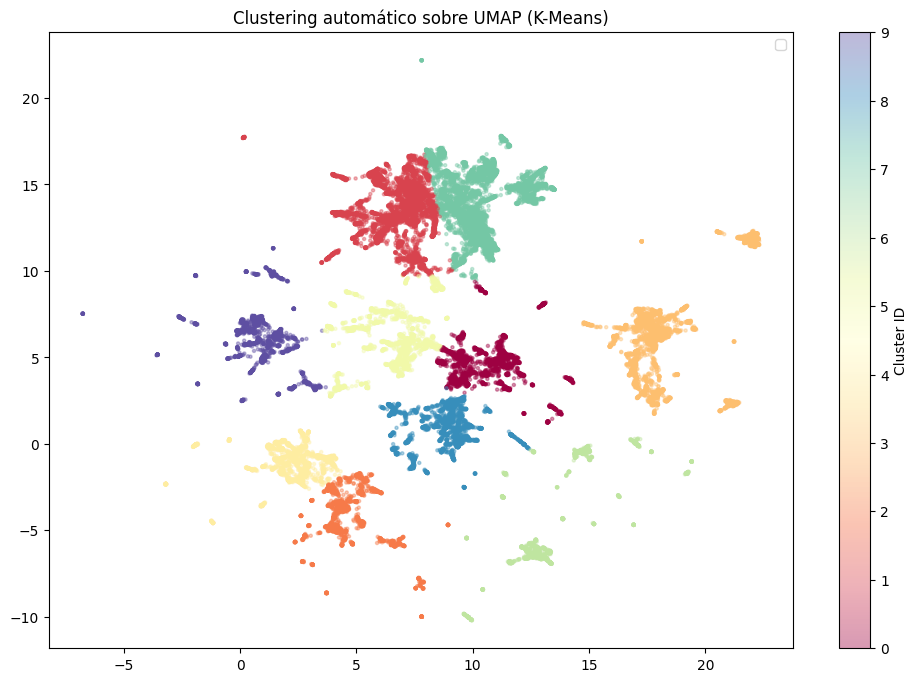

In [43]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import umap

reducer = umap.UMAP(n_components=2, random_state=42, transform_seed=42)
embedding_local_2d = reducer.fit_transform(np.stack(embeddings))

n_clusters = 10
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(embedding_local_2d)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    embedding_local_2d[:, 0], 
    embedding_local_2d[:, 1], 
    c=cluster_labels,
    cmap='Spectral',
    alpha=0.4, 
    s=5
)

plt.legend()
plt.colorbar(scatter, label="Cluster ID")
plt.title("Clustering automático sobre UMAP (K-Means)")

### 3.2 Contexto (la propia información de la reseña)

In [14]:
def process_review(df, users, businesses):
    users_mean_avg_stars = users.select(pl.col("average_stars")).mean().item()
    df = (
        df.with_columns(
            (
                pl.col("funny")
                / (pl.col("useful") + pl.col("funny") + pl.col("cool") + 1)
            ).alias("polarization"),
            (pl.col("funny") + 1).log10().alias("funny_log"),
            (pl.col("useful") + 1).log10().alias("useful_log"),
            (pl.col("cool") + 1).log10().alias("cool_log"),
            pl.col("date").dt.month().alias("month"),
            pl.col("date").dt.weekday().alias("weekday"),
            pl.col("date").dt.year().alias("year"),
            pl.col("date").dt.is_business_day().alias("is_weekend"),
            pl.col("datetime").dt.hour().alias("hour"),
        )
        .join(
            users.select(
                pl.col("user_id"),
                pl.col("average_stars").alias("avg_stars_user"),
                pl.col("elite"),
                pl.col("fans"),
            ),
            on="user_id",
            how="left",
        )
        .join(
            businesses.select(
                pl.col("business_id"), pl.col("stars").alias("avg_stars_biz")
            ),
            on="business_id",
            how="left",
        )
        .with_columns(
            (pl.col("year") - 2000).alias("year_diff"),
            pl.col("elite").str.split(",").list.eval(pl.element().cast(pl.Int32))
        )
        .with_columns(pl.col("elite").list.contains(pl.col("year")).fill_null(False))
        .with_columns(
            pl.col("fans").fill_null(0).alias("fans"),
            pl.col("avg_stars_user")
            .fill_null(users_mean_avg_stars),
        )
        .drop(["funny", "useful", "cool", "date", "datetime", "year"])
    )

    return df


train_df = process_review(train, users, businesses)
train_df.write_parquet(DATA_DIR / "train.parquet")
test_df = process_review(test, users, businesses)
test_df.write_parquet(DATA_DIR / "test.parquet")

print("Train sample:")
display(train_df.head())

print("Test sample:")
display(test_df.head())

Train sample:


review_id,user_id,business_id,stars,polarization,funny_log,useful_log,cool_log,month,weekday,is_weekend,hour,avg_stars_user,elite,fans,avg_stars_biz,year_diff
str,str,str,f64,f64,f64,f64,f64,i8,i8,bool,i8,f64,bool,i64,f64,i32
"""ZZO43qKB-s65zplC8RfJqw""","""-1BSu2dt_rOAqllw9ZDXtA""","""smkZq4G1AOm4V6p3id5sww""",5.0,0.0,0.0,0.0,0.0,9,5,true,15,4.08,false,0,4.5,16
"""vojXOF_VOgvuKD95gCO8_Q""","""xpe178ng_gj5X6HgqtOing""","""96_c_7twb7hYRZ9HHrq01g""",1.0,0.0,0.0,0.477121,0.30103,12,3,true,14,2.89,false,0,2.5,20
"""KwxdbiseRlIRNzpgvyjY0Q""","""axbaerf2Fk92OB4b9_peVA""","""e0AYjKfSF0DL-5C1CpOq6Q""",4.0,0.0,0.0,0.0,0.0,9,3,true,16,3.75,false,0,2.5,13
"""3mwoBcTy-2gMh0L91uaIeA""","""_GOiybb0rImYKJfwyxEaGg""","""vF-uptiQ34pVLHJKzPHUlA""",5.0,0.0,0.0,0.0,0.0,3,6,false,12,3.79,false,1,4.5,19
"""XfWf7XsBWs3kYyYq7Ns1ZQ""","""ojWKg3B5pH3ncAsxun3kUw""","""X28XK71RuEXPapeyUOwNzg""",5.0,0.181818,0.69897,1.041393,0.90309,4,4,true,18,4.2,false,6,4.0,20


Test sample:


review_id,user_id,business_id,polarization,funny_log,useful_log,cool_log,month,weekday,is_weekend,hour,avg_stars_user,elite,fans,avg_stars_biz,year_diff
str,str,str,f64,f64,f64,f64,i8,i8,bool,i8,f64,bool,i64,f64,i32
"""ieYPmCImINjPzTDFmEKBKA""","""79F9QrQSet-b1yRCIM243Q""","""sXSUzImYOcRRI3xtG2M85g""",0.0,0.0,0.30103,0.30103,1,1,true,4,4.11,false,2,4.5,18
"""QIkJ8fZ4yx_QaHahWWszAA""","""chuM6TBkFHtTwJ6z96Hj1A""","""Ipt9ga67vVC_2ob3YmVwNA""",0.0,0.0,0.69897,0.477121,1,1,true,3,3.77,true,19,4.0,11
"""seR2KhblYMWg-k9zzN6aYA""","""hF68a0mpu97u0oaryFYhyg""","""_RG4IByyBR528CMc7DefJA""",0.0,0.0,0.477121,0.0,9,7,false,15,2.92,false,2,3.5,15
"""BToo00Fi5pfJFA5MI2HM5g""","""G4yX5Q1tFfwSucFOmiyjdA""","""xxlbRiWWQkk-6LST3Hd12g""",0.0,0.0,0.477121,0.0,9,1,true,0,3.82,false,10,4.0,15
"""FHJAzi1imodBit3RWK7zQA""","""Srqi1xb7exdB9uRHxDeEkw""","""LgGqdFLD7-ca0Z9F_q4Fuw""",0.0,0.0,0.0,0.0,7,5,true,1,1.25,false,0,2.5,15


## 4. Entrenamiento de los modelos

### 4.1 Entrenamiento de TabNet para usuarios

In [16]:
from pytorch_tabnet.tab_model import TabNetRegressor
from sklearn.model_selection import train_test_split

X_train = user_df.drop([c for c in ["user_id", "average_stars", "embedding"] if c in user_df.columns]).to_numpy()
y_train = user_df.select("average_stars").to_numpy().flatten().reshape(-1, 1)

X_train_part, X_val, y_train_part, y_val = train_test_split(X_train, y_train, test_size=0.2)

reg = TabNetRegressor(n_d=64, n_a=64, n_steps=5)
reg.fit(
    X_train=X_train, y_train=y_train,
    eval_set=[(X_val, y_val)],
    eval_name=['val'],
    eval_metric=['mae'],  # Métricas a usar, por ejemplo 'mae', 'mse', etc.
    max_epochs=10,
    patience=4,  # Detener si no mejora en N épocas
    batch_size=1024,
    virtual_batch_size=128
)

c:\Users\Yago\Desktop\MAADM\5 Sistemas de Recomendación\practica2\.venv\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


KeyboardInterrupt: 

In [17]:
MODELS_DIR = Path("./models")
MODELS_DIR.mkdir(exist_ok=True)
saving_path = MODELS_DIR / "tabnet_user_model"

try:
    saved_filepath = reg.save_model(saving_path)

finally:
    reg = TabNetRegressor()
    reg.load_model(saved_filepath)

reg

Successfully saved model at models\tabnet_user_model.zip


c:\Users\Yago\Desktop\MAADM\5 Sistemas de Recomendación\practica2\.venv\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


,n_d,64
,n_a,64
,n_steps,5
,gamma,1.3
,cat_idxs,[]
,cat_dims,[]
,cat_emb_dim,[]
,n_independent,2
,n_shared,2
,epsilon,1e-15
,momentum,0.02


In [ ]:
import torch

def get_tabnet_embedding(regressor, data):
    model = regressor.network.eval()
    
    with torch.no_grad():
        X = torch.tensor(data, dtype=torch.float32)
        res = model.tabnet.encoder(X)
        steps_output, _ = res
        embedding = torch.sum(torch.stack(steps_output, dim=0), dim=0)

    return embedding.numpy()

embeddings_user = get_tabnet_embedding(reg, X_train)
user_df = user_df.with_columns(
    pl.Series(name="embedding", values=list(embeddings_user)).alias("embedding")
)
user_df.write_parquet(DATA_DIR / "user_embeddings.parquet")
embeddings_user

array([[8.3262928e-02, 9.1129217e+00, 1.6582195e+01, ..., 1.1805082e-01,
        4.0496502e+00, 3.5091141e+01],
       [6.1084585e+00, 6.1883512e+00, 2.4597909e+00, ..., 7.4678144e+00,
        9.7004223e+00, 0.0000000e+00],
       [0.0000000e+00, 9.9377596e-01, 1.6627136e+01, ..., 5.8673507e-01,
        9.2927246e+00, 3.2172764e+01],
       ...,
       [3.7747227e-02, 4.1102890e-02, 1.8612671e-01, ..., 6.1985239e-02,
        8.7504007e-02, 0.0000000e+00],
       [3.0838136e-02, 7.8528240e-02, 1.3365678e-01, ..., 2.7995678e-02,
        7.7242933e-02, 0.0000000e+00],
       [3.7509516e-02, 2.7360842e-02, 1.8875712e-01, ..., 6.3482538e-02,
        8.3886601e-02, 0.0000000e+00]], shape=(699619, 64), dtype=float32)

In [ ]:
from pprint import pprint
sample_to_show = 0
pprint(user_df.drop([c for c in ["user_id", "average_stars", "embedding"] if c in user_df.columns]).schema)
reg.predict(X_val[[sample_to_show]]), get_tabnet_embedding(reg, X_val[[sample_to_show]]), reg.explain(X_val[[sample_to_show]])

Schema([('user_review_count_log', Float64),
        ('user_fans_log', Float64),
        ('user_useful_log', Float64),
        ('user_funny_log', Float64),
        ('user_cool_log', Float64),
        ('friends_count_log', Float64),
        ('elite_count', UInt32),
        ('user_bias', Float64),
        ('useful_per_review', Float64),
        ('funny_per_review', Float64),
        ('cool_per_review', Float64),
        ('comp_total_log', Float64),
        ('comp_writer_log', Float64),
        ('comp_photos_log', Float64),
        ('years_active', Float64)])


(array([[1.5462017]], dtype=float32),
 array([[0.03636925, 0.09215298, 0.200323  , 0.13908988, 0.2286481 ,
         0.03976541, 0.06174313, 0.01013469, 0.17690966, 0.0946155 ,
         0.19844173, 0.22846805, 0.05791103, 0.1623022 , 0.1926055 ,
         0.08173529, 0.        , 0.19530275, 0.        , 0.16879722,
         0.00907461, 0.22285572, 0.38463354, 0.06439538, 0.44588104,
         0.38082024, 0.2662184 , 0.52923137, 0.01917478, 0.06955767,
         0.        , 0.05009951, 0.1674402 , 0.15040566, 0.        ,
         0.22694945, 0.03181929, 0.08740601, 0.25141212, 0.1926435 ,
         0.        , 0.41287738, 0.03387366, 0.12817626, 0.        ,
         0.00416066, 0.03270804, 0.13283381, 0.05184918, 0.06212795,
         0.04259551, 0.06895318, 0.4783464 , 0.06823523, 0.01872118,
         0.06784805, 0.01145243, 0.21559042, 0.22986923, 0.        ,
         0.15013129, 0.06106821, 0.08630057, 0.        ]], dtype=float32),
 (array([[0.13501243, 0.50391072, 0.        , 0.71287966, 0

c:\Users\Yago\Desktop\MAADM\5 Sistemas de Recomendación\practica2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP dimensionality reduction completed in 103.34 seconds.
K-Means clustering completed in 0.11 seconds.


C:\Users\Yago\AppData\Local\Temp\ipykernel_10084\3368844298.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0.5, 1.0, 'Clustering automático sobre UMAP (K-Means)')

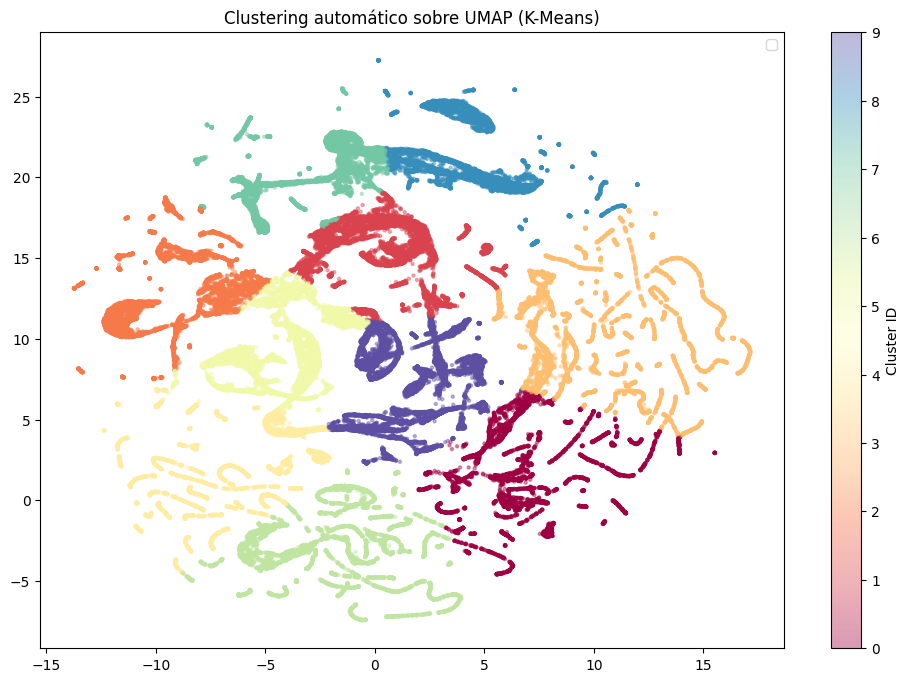

In [50]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import umap
import datetime

start = datetime.datetime.now()

n_samples = 70_000 
if len(embeddings_user) > n_samples:
    np.random.seed(42)
    indices = np.random.choice(len(embeddings_user), n_samples, replace=False)
    embeddings_subset = embeddings_user[indices]
else:
    embeddings_subset = embeddings_user

reducer = umap.UMAP(n_components=2, random_state=42, transform_seed=42, low_memory=True, n_jobs=-1)
embedding_user_2d = reducer.fit_transform(embeddings_subset)

print(f"UMAP dimensionality reduction completed in {(datetime.datetime.now() - start).total_seconds():.2f} seconds.")
start = datetime.datetime.now()
n_clusters = 10
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(embedding_user_2d)

print(f"K-Means clustering completed in {(datetime.datetime.now() - start).total_seconds():.2f} seconds.")

plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    embedding_user_2d[:, 0], 
    embedding_user_2d[:, 1], 
    c=cluster_labels,
    cmap='Spectral',
    alpha=0.4, 
    s=5
)

plt.legend()
plt.colorbar(scatter, label="Cluster ID")
plt.title("Clustering automático sobre UMAP (K-Means)")